In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [2]:
dataset_path = r"C:\Users\Acer\Documents\data\smile"

smile_path = os.path.join(dataset_path, "smile")
non_smile_path = os.path.join(dataset_path, "non_smile")

print("Smile:", len(os.listdir(smile_path)))
print("Non-Smile:", len(os.listdir(non_smile_path)))

Smile: 600
Non-Smile: 603


In [3]:
IMG_SIZE = 64
images = []
labels = []
for filename in os.listdir(smile_path):
    path = os.path.join(smile_path, filename)
    img = cv2.imread(path)

    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        images.append(img)
        labels.append(1)

for filename in os.listdir(non_smile_path):
    path = os.path.join(non_smile_path, filename)
    img = cv2.imread(path)

    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        images.append(img)
        labels.append(0)

print("Total images:", len(images))
print("Total labels:", len(labels))

Total images: 1203
Total labels: 1203


In [4]:
X = np.array(images)
y = np.array(labels)

indices = np.random.permutation(len(X))

X = X[indices]
y = y[indices]

print(X.shape)
print(y.shape)

(1203, 64, 64, 3)
(1203,)


In [5]:
X = X.astype("float32") / 255.0

print(X.min())
print(X.max())

0.0
1.0


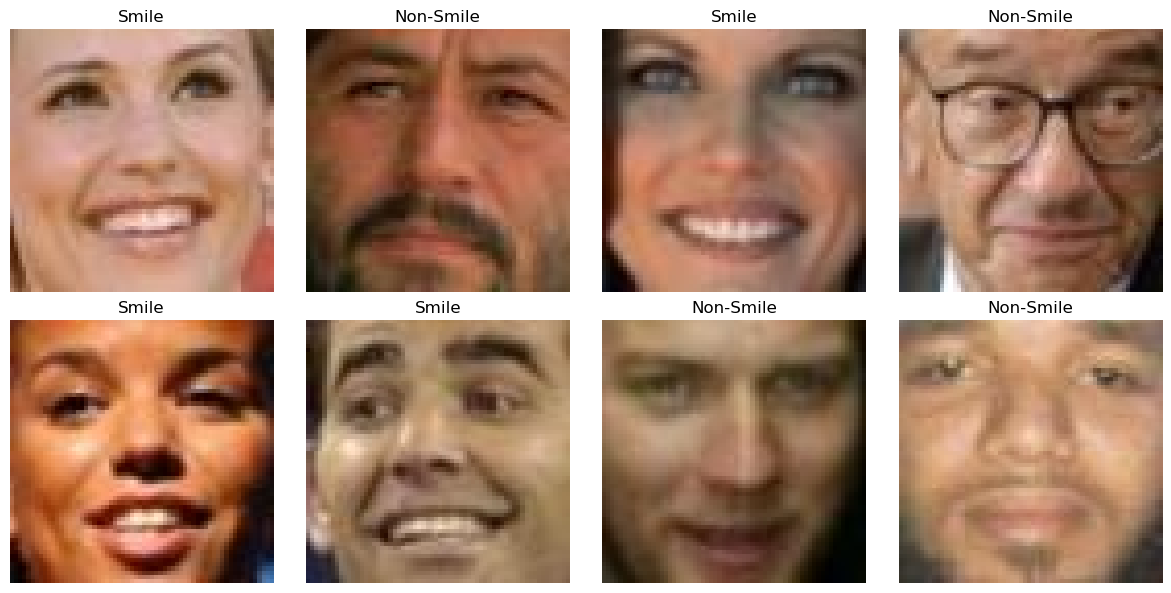

In [6]:
plt.figure(figsize=(12, 6))

random_indices = np.random.choice(len(X), 8, replace=False)

for i, idx in enumerate(random_indices):

    plt.subplot(2, 4, i + 1)

    plt.imshow(X[idx])

    if y[idx] == 1:
        plt.title("Smile")
    else:
        plt.title("Non-Smile")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True,stratify=y)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (962, 64, 64, 3)
Test: (241, 64, 64, 3)


In [8]:
model = Sequential([Conv2D(64, (3, 3), activation="relu",input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(16, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(8, (3, 3), activation="relu"),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.summary()

C:\Users\Acer\anaconda3\New folder\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 4, 4, 8)             │           1,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 42,681 (166.72 KB)

 Trainable params: 42,681 (166.72 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

history = model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2,shuffle=True)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 119ms/step - accuracy: 0.4993 - loss: 0.6949 - val_accuracy: 0.4663 - val_loss: 0.6934
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.5397 - loss: 0.6918 - val_accuracy: 0.4767 - val_loss: 0.6933
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.6372 - loss: 0.6772 - val_accuracy: 0.7513 - val_loss: 0.6391
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.7126 - loss: 0.6068 - val_accuracy: 0.8031 - val_loss: 0.4998
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.8088 - loss: 0.4542 - val_accuracy: 0.8653 - val_loss: 0.3856
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.8648 - loss: 0.3673 - val_accuracy: 0.8860 - val_loss: 0.3127
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.8726 - loss: 0.3268 - val_accuracy: 0.9119 - val_loss: 0.2747
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.9038 - loss: 0.2702 - val_accuracy: 0.8912 -

In [10]:
test_loss, test_accuracy = model.evaluate(X_test,y_test,verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9295 - loss: 0.1928
Test Loss: 0.19284048676490784
Test Accuracy: 0.9294605851173401


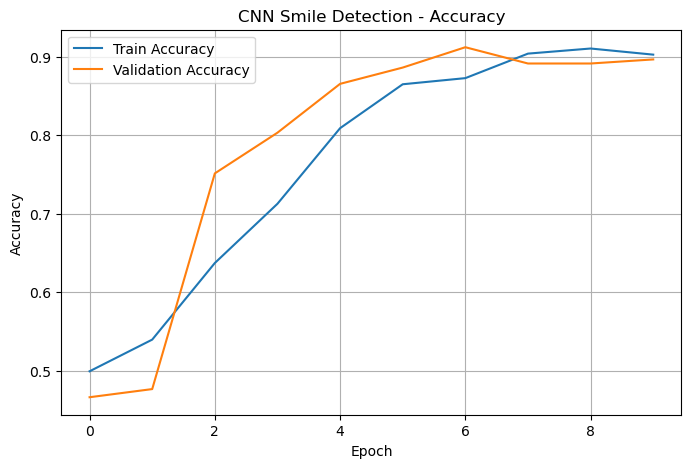

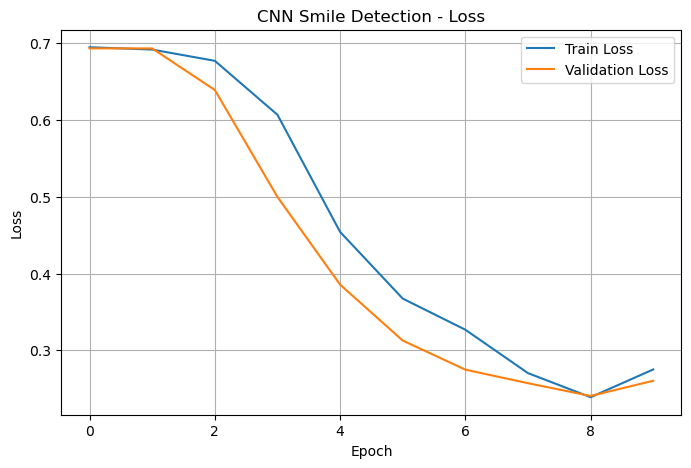

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Smile Detection - Accuracy")
plt.legend()
plt.grid()


plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Smile Detection - Loss")
plt.legend()
plt.grid()

plt.show()

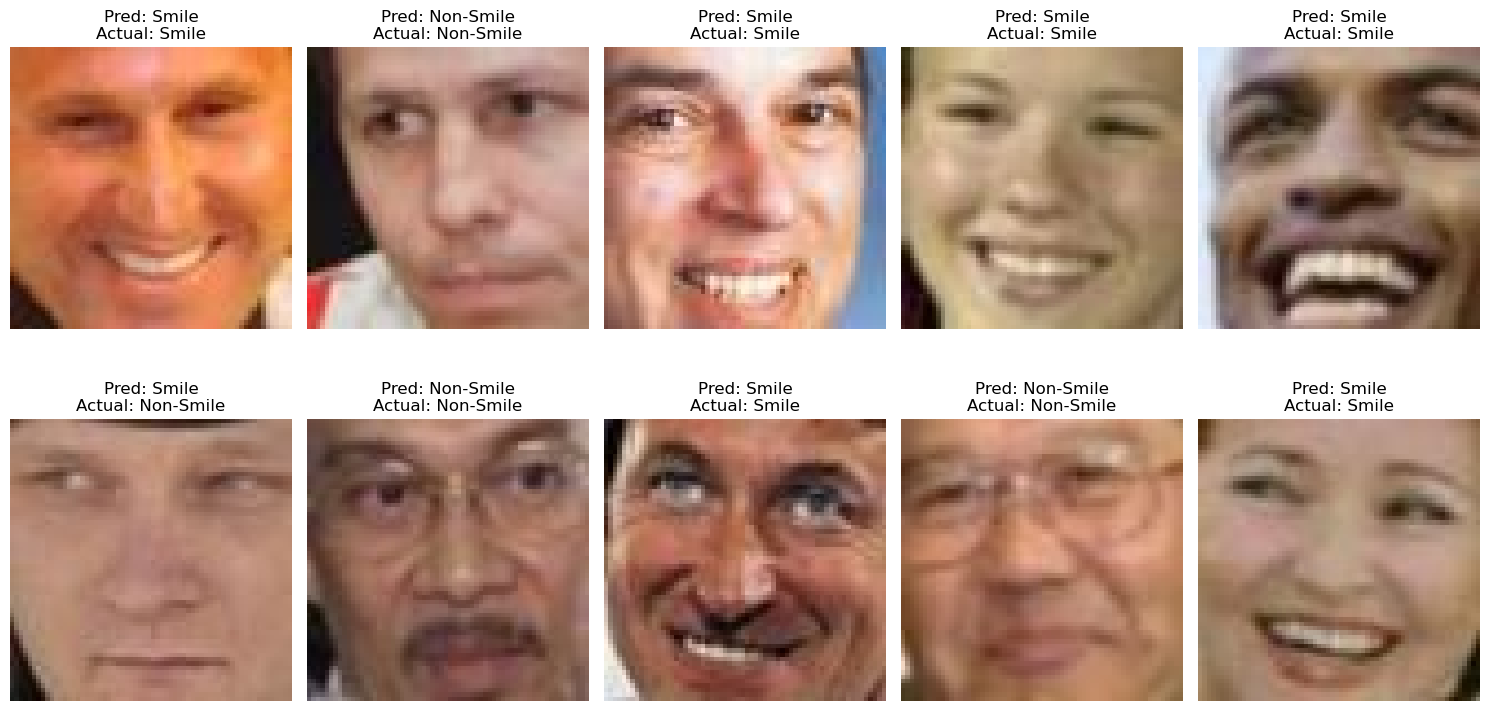

In [13]:
plt.figure(figsize=(15, 8))
random_indices = np.random.choice(len(X_test), 10, replace=False)
for i, idx in enumerate(random_indices):
    img = X_test[idx]
    prediction = model.predict(np.expand_dims(img, axis=0),verbose=0)[0][0]
    if prediction >= 0.5:
        predicted_label = "Smile"
    else:
        predicted_label = "Non-Smile"

    if y_test[idx] == 1:
        actual_label = "Smile"
    else:
        actual_label = "Non-Smile"

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)

    plt.title(f"Pred: {predicted_label}\nActual: {actual_label}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
model.save("smile_cnn_model.keras")

print("Model saved successfully!")

Model saved successfully!
